## CONTEXTO

**Barreras a la Formación (EAL-24)** y **Motivos de No Formación (EAL-25)**

### Resumen de Tablas: Análisis de Barreras y Limitaciones

| Código de Tabla | Descripción del Contenido | Relevancia para el Proyecto |
| :--- | :--- | :--- |
| **EAL-24** | **Barreras Generales:** Grado de limitación (nada a mucho) de 10 motivos específicos en empresas que **SÍ** proporcionaron formación. | Proporciona la línea base nacional para entender qué dificultades encuentran las empresas al intentar formar. |
| **EAL-24c** | **Barreras en Grandes Empresas:** Mismo desglose que la EAL-24 pero exclusivo para empresas de **más de 499 trabajadores**. | **Es la tabla prioritaria.** Al ser RapidExpress una gran empresa, estos datos reflejan sus retos específicos (ej. carga de trabajo). |
| **EAL-24f** | **Barreras en el Sector Servicios:** Limitaciones detectadas específicamente en las empresas de servicios que sí forman. | Permite contrastar si las barreras de nuestro sector (Transporte) son más agudas que en el resto de servicios. |
| **EAL-25** | **Motivos de No Formación:** Grado de influencia de factores que llevaron a la decisión de **NO** proporcionar formación. | Útil para identificar por qué otras empresas del mercado deciden no invertir en el desarrollo de su personal. |
| **EAL-25b** | **Inacción en Medianas/Grandes Empresas:** Motivos de no formación en empresas de **50 o más trabajadores**. | Se utiliza como **referencia (proxy)** para entender las razones estratégicas o logísticas de inacción en organizaciones de mayor tamaño. |
| **EAL-25e** | **No Formación en Servicios:** Razones de peso por las que el sector servicios decide no realizar acciones formativas. | Ayuda a diagnosticar si en nuestro entorno la falta de formación se debe a una "decisión estratégica" o a "barreras reales". |


**Nota Metodológica:** Todas las comparaciones entre porcentajes de estas tablas (especialmente entre **EAL-24c** y el resto) serán validadas mediante **tests de diferencias de proporciones (Z-test)** para asegurar que los hallazgos sean estadísticamente significativos

## 1. Fase de EDA Simple (Dataset 2024)
Antes de filtrar, realizamos una exploración general de las barreras en el sector servicios y el segmento de grandes empresas:

In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

In [193]:
df_barreras= pd.read_csv('../../Data/clean/EAL_15062025/2024/df_limitaciones.csv')

In [194]:
df_barreras

,anio,tabla,proporcionaron_formacion,pregunta,ambito,NADA,POCO,BASTANTE,MUCHO
0,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El nivel de formación de los empleados era el ...,8.964,19.548,53.724,17.765
1,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La empresa prefirió contratar a personal con l...,21.954,25.684,39.843,12.519
2,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,Dificultad para evaluar la necesidades de form...,31.450,51.904,14.719,1.928
3,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La falta de cursos de formación adecuados en e...,26.775,45.123,20.708,7.394
4,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El alto coste de los cursos de formación,21.532,36.681,28.491,13.295
5,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La empresa prefirió tener personal con contrat...,68.584,23.204,6.415,1.797
6,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El mayor esfuerzo realizado en años anteriores...,32.592,42.286,20.426,4.696
7,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La elevada carga de trabajo y el escaso tiempo...,15.221,28.392,39.031,17.356
8,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,Dificultad para acceder a ayudas o subvencione...,25.833,36.915,23.157,14.095
9,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,Otras razones,68.296,22.730,5.969,3.004


In [195]:
df_barreras.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   anio                      60 non-null     int64  
 1   tabla                     60 non-null     object 
 2   proporcionaron_formacion  60 non-null     object 
 3   pregunta                  60 non-null     object 
 4   ambito                    60 non-null     object 
 5   NADA                      60 non-null     float64
 6   POCO                      60 non-null     float64
 7   BASTANTE                  60 non-null     float64
 8   MUCHO                     60 non-null     float64
dtypes: float64(4), int64(1), object(4)
memory usage: 4.3+ KB


In [196]:
df_barreras.shape

(60, 9)

In [197]:
df_barreras.describe().round(2)

,anio,NADA,POCO,BASTANTE,MUCHO
count,60.0,60.00,60.00,60.00,60.00
mean,2024.0,33.80,32.89,23.70,9.62
std,0.0,18.34,11.42,13.92,7.75
min,2024.0,6.46,11.74,5.01,0.17
25%,2024.0,21.49,23.09,14.93,3.18
50%,2024.0,31.43,33.78,20.27,7.31
75%,2024.0,36.90,42.14,31.17,13.64
max,2024.0,70.07,55.21,53.72,33.19


La mayoría de las barreras son percibidas como poco o nada importantes, aunque algunas destacan claramente sobre el resto y llegan a ser consideradas obstáculos relevantes por una proporción significativa de empresas.

In [198]:
df_barreras.columns

Index(['anio', 'tabla', 'proporcionaron_formacion', 'pregunta', 'ambito',
       'NADA', 'POCO', 'BASTANTE', 'MUCHO'],
      dtype='object')

### **Distribución de frecuencias:** 

Generamos tablas de frecuencias para las respuestas "Bastante" y "Mucho" de las tablas **EAL-24c** (>499 trabajadores) y **EAL-25b** (>=50 trabajadores).

Primero creamos columna RELEVANCIA

In [199]:
df_relevancia=df_barreras.copy()

In [200]:
# Creamos el índice de RELEVANCIA (Top-2-Box)
df_relevancia['RELEVANCIA'] = df_relevancia['BASTANTE'] + df_relevancia['MUCHO']

# Visualización rápida de la estructura
print(f"Dataset cargado: {df_relevancia.shape} filas.")
df_relevancia.head()


Dataset cargado: (60, 10) filas.


,anio,tabla,proporcionaron_formacion,pregunta,ambito,NADA,POCO,BASTANTE,MUCHO,RELEVANCIA
0,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El nivel de formación de los empleados era el ...,8.964,19.548,53.724,17.765,71.489
1,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La empresa prefirió contratar a personal con l...,21.954,25.684,39.843,12.519,52.362
2,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,Dificultad para evaluar la necesidades de form...,31.450,51.904,14.719,1.928,16.647
3,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La falta de cursos de formación adecuados en e...,26.775,45.123,20.708,7.394,28.102
4,2024,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El alto coste de los cursos de formación,21.532,36.681,28.491,13.295,41.786


> Se aplicó la técnica **Top-2-Box**, que consiste en agrupar las respuestas **"Bastante"** y **"Mucho"** en un único indicador de **relevancia**. Esta transformación simplifica la interpretación de los resultados, facilita la elaboración de rankings y permite identificar rápidamente las barreras, competencias o necesidades formativas más importantes para las empresas. Además, mejora la comparabilidad entre sectores y hace más clara la visualización de los hallazgos para la toma de decisiones, convirtiéndose en un indicador clave para priorizar las acciones de RRHH.

#### Barreras grandes empresas formadoras

In [201]:
# 1. Empresas de >499 que SÍ proporcionaron formación (EAL-24c)
print("--- RELEVANCIA DE BARRERAS EN GRANDES EMPRESAS (>499) ---")
resumen_24c = df_relevancia[df_relevancia['tabla'] == 'EAL-24c'][['ambito', 'RELEVANCIA', 'BASTANTE', 'MUCHO']].sort_values(by='RELEVANCIA', ascending=False)
print(resumen_24c)

--- RELEVANCIA DE BARRERAS EN GRANDES EMPRESAS (>499) ---
                                               ambito  RELEVANCIA  BASTANTE  \
17  La elevada carga de trabajo y el escaso tiempo...      55.056    41.209   
10  El nivel de formación de los empleados era el ...      53.291    47.697   
11  La empresa prefirió contratar a personal con l...      37.747    31.742   
14           El alto coste de los cursos de formación      37.570    30.667   
18  Dificultad para acceder a ayudas o subvencione...      23.046    17.307   
16  El mayor esfuerzo realizado en años anteriores...      21.776    19.701   
13  La falta de cursos de formación adecuados en e...      19.895    17.182   
12  Dificultad para evaluar la necesidades de form...      13.504    12.062   
19                                      Otras razones       7.474     5.614   
15  La empresa prefirió tener personal con contrat...       5.560     5.012   

     MUCHO  
17  13.847  
10   5.594  
11   6.005  
14   6.903  
18   5.

#### Barreras empresas no formadoras

In [202]:
# 2. Empresas de >=50 que NO proporcionaron formación (EAL-25b)
print("\n--- RELEVANCIA DE MOTIVOS PARA NO FORMAR (>=50 emp.) ---")
resumen_25b = df_relevancia[df_relevancia['tabla'] == 'EAL-25b'][['ambito', 'RELEVANCIA', 'BASTANTE', 'MUCHO']].sort_values(by='RELEVANCIA', ascending=False)
print(resumen_25b)


--- RELEVANCIA DE MOTIVOS PARA NO FORMAR (>=50 emp.) ---
                                               ambito  RELEVANCIA  BASTANTE  \
40  El nivel de formación de los empleados era el ...      73.978    49.030   
41  La empresa prefirió contratar a personal con l...      62.547    41.856   
47  La elevada carga de trabajo y el escaso tiempo...      40.794    28.625   
48  Dificultad para acceder a ayudas o subvencione...      27.367    17.212   
44           El alto coste de los cursos de formación      25.999    15.092   
46  El mayor esfuerzo realizado en años anteriores...      24.215    24.049   
42  Dificultad para evaluar la necesidades de form...      19.761    17.449   
49                                      Otras razones      17.667     7.505   
43  La falta de cursos de formación adecuados en e...      17.157    11.290   
45  La empresa prefirió tener personal con contrat...       9.070     8.904   

     MUCHO  
40  24.948  
41  20.691  
47  12.169  
48  10.155  
44  10.

#### **Visualizaciones iniciales:** 

Creamos diagramas de barras para identificar visualmente cuál es la barrera predominante.


/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_42478/3097358798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_24c, x='RELEVANCIA', y='ambito', palette='viridis')


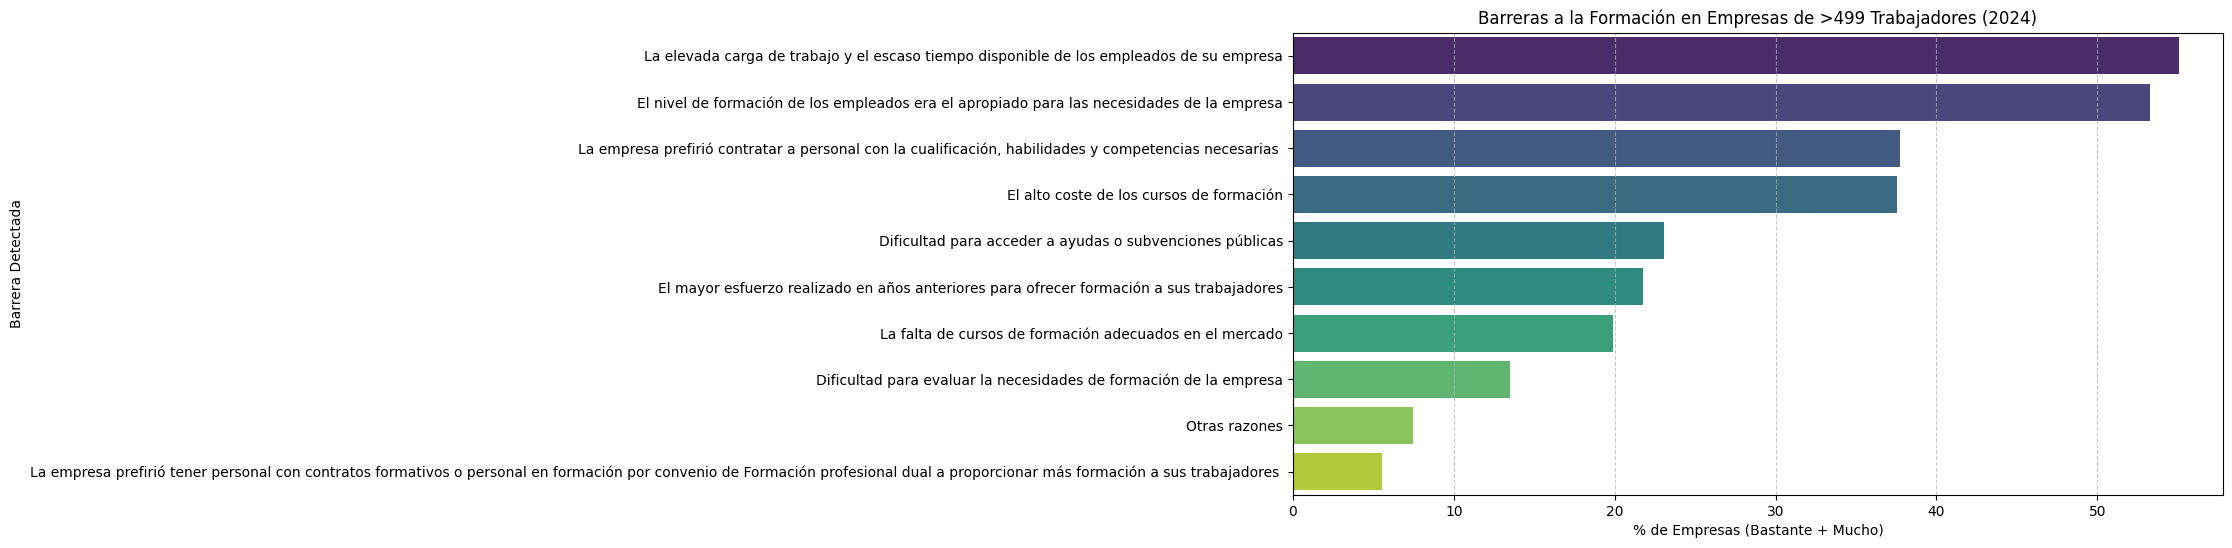

In [203]:
plt.figure(figsize=(12, 6))
sns.barplot(data=resumen_24c, x='RELEVANCIA', y='ambito', palette='viridis')
plt.title('Barreras a la Formación en Empresas de >499 Trabajadores (2024)')
plt.xlabel('% de Empresas (Bastante + Mucho)')
plt.ylabel('Barrera Detectada')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Confirmamos visualmente que la "elevada carga de trabajo y escaso tiempo" es el factor crítico en las grandes organizaciones que si dieron formación. Casi a la par, se el "nivel de formación apropiado a las necesidades" es otra barrera importante que encontraban las empresas formadoras.

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_42478/1576633823.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_25b, x='RELEVANCIA', y='ambito', palette='viridis')


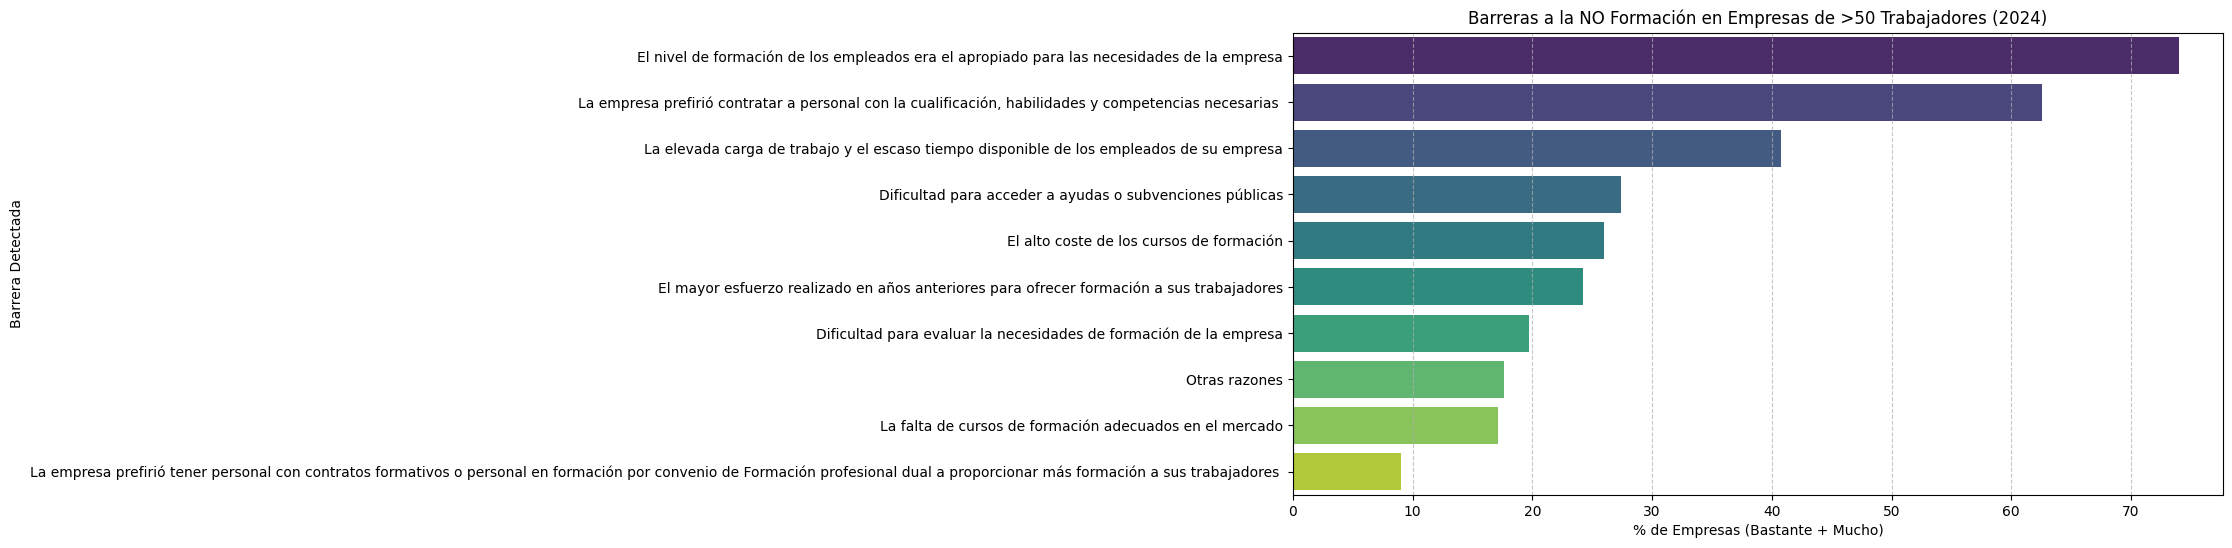

In [204]:
plt.figure(figsize=(12, 6))
sns.barplot(data=resumen_25b, x='RELEVANCIA', y='ambito', palette='viridis')
plt.title('Barreras a la NO Formación en Empresas de >50 Trabajadores (2024)')
plt.xlabel('% de Empresas (Bastante + Mucho)')
plt.ylabel('Barrera Detectada')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Motivos de inacción:

Las organizaciones que no dieron formación consideran como factor critico el "nivel de formación apropiado a las necesidades" (auto-suficiencia percibida) junto con la decisión de "contratar a personal cualificado" (contratación externa) en lugar de desarrollar talento interno

### **Detección de Atípicos:** 

Aunque trabajamos con datos agregados, revisaremos si hay alguna barrera que tenga un comportamiento extremadamente inusual en comparación con el total nacional. Compararemos el segmento de grandes empresas (EAL-24c) contra el Total Nacional (EAL-24):

In [205]:
#Pivotamos los datos para comparar el segmento vs el total
comparativa = df_relevancia[df_relevancia['tabla'].isin(['EAL-24', 'EAL-24c'])].pivot(index='ambito', columns='tabla', values='RELEVANCIA')
comparativa['Diferencia_Puntos'] = comparativa['EAL-24c'] - comparativa['EAL-24']

In [206]:
#Detectamos "Atípicos" (Diferencias significativas > 5 o 10 puntos)
print("--- COMPARATIVA: GRANDES EMPRESAS VS TOTAL NACIONAL ---")
print(comparativa.sort_values(by='Diferencia_Puntos', ascending=False))

--- COMPARATIVA: GRANDES EMPRESAS VS TOTAL NACIONAL ---
tabla                                               EAL-24  EAL-24c  \
ambito                                                                
La elevada carga de trabajo y el escaso tiempo ...  56.387   55.056   
Otras razones                                        8.973    7.474   
La empresa prefirió tener personal con contrato...   8.212    5.560   
Dificultad para evaluar la necesidades de forma...  16.647   13.504   
El mayor esfuerzo realizado en años anteriores ...  25.122   21.776   
El alto coste de los cursos de formación            41.786   37.570   
La falta de cursos de formación adecuados en el...  28.102   19.895   
Dificultad para acceder a ayudas o subvenciones...  37.252   23.046   
La empresa prefirió contratar a personal con la...  52.362   37.747   
El nivel de formación de los empleados era el a...  71.489   53.291   

tabla                                               Diferencia_Puntos  
ambito             

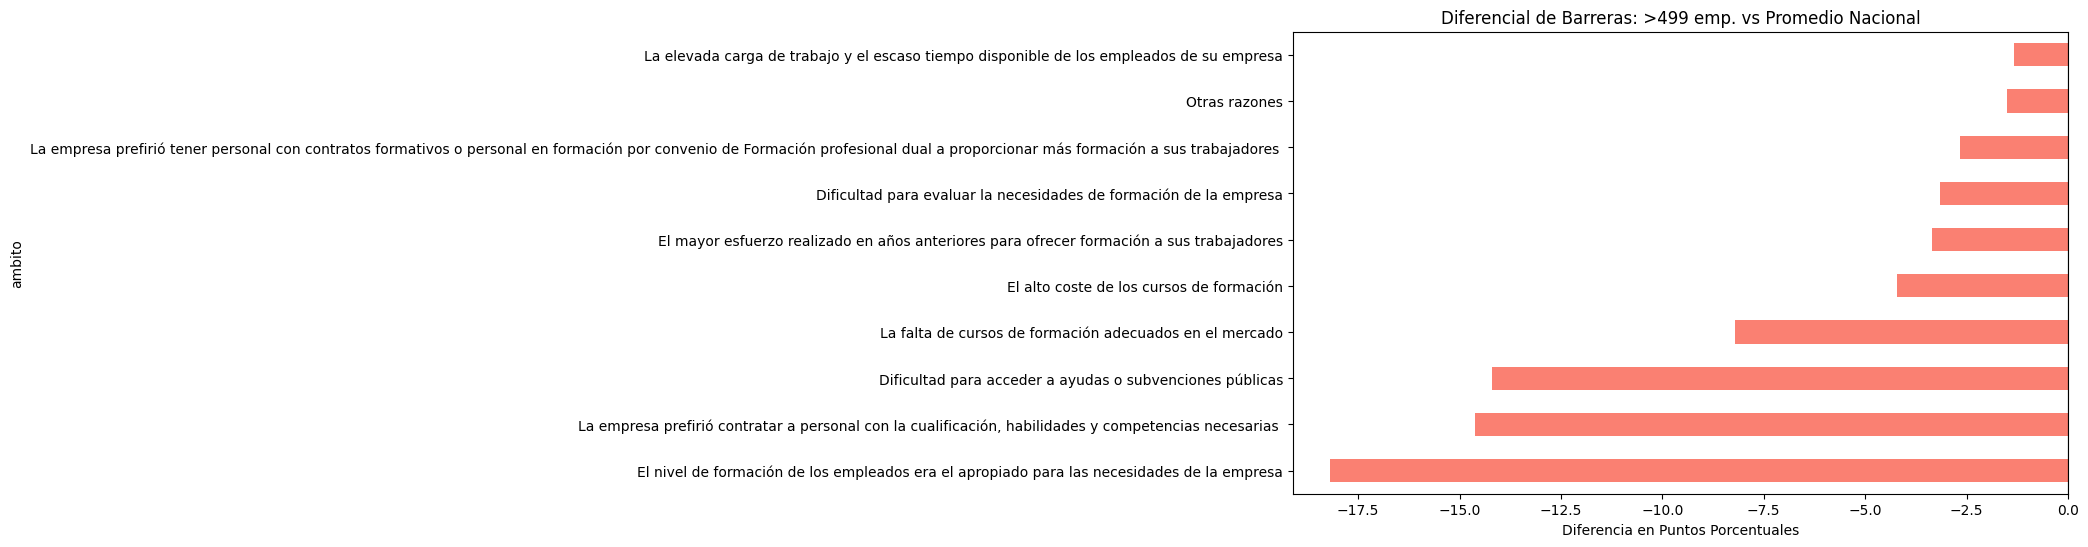

In [207]:
comparativa['Diferencia_Puntos'].sort_values().plot(kind='barh', color='salmon', figsize=(10,6))
plt.title('Diferencial de Barreras: >499 emp. vs Promedio Nacional')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Diferencia en Puntos Porcentuales')
plt.show()

> El análisis comparativo muestra que las empresas de más de 499 trabajadores perciben **menos barreras para la formación que la media nacional**. Sin embargo, también son **menos propensas a considerar que el nivel formativo de su plantilla ya es suficiente**, lo que sugiere una mayor orientación hacia el desarrollo continuo de competencias y una mayor exigencia en materia de formación.

#### Validación de Atípicos

Basándonos en el Informe Metodológico, los tamaños de muestra (n) para el año 2024 son:
- Grandes Empresas (>499 trabajadores): n=1.992 empresas.
- Sector Servicios (Total): n=5.963 empresas (suma de los subsectores G a S del informe).

In [208]:
n_499 = 1992
n_servicios = 5963

In [209]:
cols = ['BASTANTE', 'MUCHO']

Al agrupar "Bastante" y "Mucho", estamos tratando la respuesta como una variable dicotómica (Relevante / No Relevante), lo cual es el supuesto necesario para aplicar Z-test

In [210]:
resultados = []

In [211]:

# Obtener todas las barreras de la tabla >499
barreras = df_relevancia[
    df_relevancia['tabla'] == 'EAL-24c'
]['ambito'].unique()

for barrera in barreras:

    filtro_499 = df_relevancia[
        (df_relevancia['tabla'] == 'EAL-24c') &
        (df_relevancia['ambito'] == barrera)
    ]

    filtro_servicios = df_relevancia[
        (df_relevancia['tabla'] == 'EAL-24f') &
        (df_relevancia['ambito'] == barrera)
    ]

    if filtro_499.empty or filtro_servicios.empty:
        continue

    p1 = filtro_499[cols].sum(axis=1).iloc[0]
    p2 = filtro_servicios[cols].sum(axis=1).iloc[0]

    count = [
        round(p1 * n_499 / 100),
        round(p2 * n_servicios / 100)
    ]

    nobs = [n_499, n_servicios]

    stat, p_value = proportions_ztest(count, nobs)

    resultados.append({
        'Barrera': barrera,
        'Relevancia >499 (%)': round(p1, 2),
        'Relevancia Servicios (%)': round(p2, 2),
        'Diferencia (pp)': round(p1 - p2, 2),
        'Z': round(stat, 3),
        'p-valor': round(p_value, 4),
        'Significativa': 'Sí' if p_value < 0.05 else 'No'
    })

df_resultados = pd.DataFrame(resultados)

# Ordenar por magnitud de diferencia
df_resultados = df_resultados.sort_values(
    by='Diferencia (pp)',
    key=abs,
    ascending=False
)

df_resultados

,Barrera,Relevancia >499 (%),Relevancia Servicios (%),Diferencia (pp),Z,p-valor,Significativa
0,El nivel de formación de los empleados era el ...,53.29,71.18,-17.89,-14.643,0.0000,Sí
1,La empresa prefirió contratar a personal con l...,37.75,53.63,-15.88,-12.273,0.0000,Sí
8,Dificultad para acceder a ayudas o subvencione...,23.05,37.40,-14.35,-11.726,0.0000,Sí
3,La falta de cursos de formación adecuados en e...,19.90,27.56,-7.67,-6.805,0.0000,Sí
4,El alto coste de los cursos de formación,37.57,42.31,-4.74,-3.739,0.0002,Sí
2,Dificultad para evaluar la necesidades de form...,13.50,16.77,-3.26,-3.447,0.0006,Sí
5,La empresa prefirió tener personal con contrat...,5.56,8.05,-2.49,-3.650,0.0003,Sí
6,El mayor esfuerzo realizado en años anteriores...,21.78,23.49,-1.71,-1.566,0.1172,No
9,Otras razones,7.47,9.12,-1.64,-2.251,0.0244,Sí
7,La elevada carga de trabajo y el escaso tiempo...,55.06,56.16,-1.10,-0.850,0.3951,No


### 2. Agregación y Clasificación Estratégica
Para que el análisis no sea solo una lista de porcentajes, agruparemos los 10 motivos de las tablas EAL-24 y EAL-25 en las categorías definidas en la justificación técnica:
*   **Factores de Tiempo/Organizativos:** Motivo 8 (carga de trabajo), motivo 1 (nivel adecuado) y motivo 2 (preferencia por contratar ya formado).
*   **Factores Económicos:** Motivo 5 (alto coste) y motivo 9 (ayudas públicas).
*   **Factores de Oferta:** Motivo 4 (falta de cursos adecuados) y motivo 3 (evaluación de necesidades).

### 3. Aplicación de Tests de Diferencias (Requisito de la Jefa)
Cuando comparemos los porcentajes de 2024 entre diferentes grupos, debemos aplicar rigor estadístico:
*   **Contraste de Proporciones:** Si comparamos el porcentaje de empresas de >499 que ven el coste como una barrera (EAL-24c) frente al total de Servicios (EAL-24f), utilizaremos un **Z-test para dos proporciones independientes**. 
*   **Interpretación del p-valor:** Solo informaremos de diferencias como "reales" si el p-valor es inferior a **0.05**. Si es superior, deberemos concluir que RapidExpress se comporta igual que la media del sector.

### 4. Preparación para el Análisis de Tendencias (Dataset Largo)
Cuando utilicemos el archivo `eal_formacion_unificado_largo.csv`, la técnica clave será el **Análisis de Series Temporales**. 
*   **Filtrado Crítico:** Deberemos filtrar por `Sección H` (Transporte y Almacenamiento) y por el tamaño de empresa de más de 499 trabajadores para que los datos sean comparables con RapidExpress.
*   **Cálculo de Variaciones:** Calcularemos la **variación absoluta** (puntos porcentuales de diferencia entre 2020 y 2024) para ver si barreras como el "teletrabajo" o la "falta de tiempo" han ganado importancia tras la pandemia.